# Importing Libraries

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


# Loading Dataset

In [12]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,Message,Class
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham


In [13]:
df.describe()

,Message,Class
count,5572,5572
unique,5169,2
top,"Sorry, I'll call later",ham
freq,30,4825


In [21]:
df.isna().sum()

Message    0
Class      0
dtype: int64

# EDA

In [15]:
# converting the labels to numbers
df['Class']= df['Class'].map({'ham': 0, 'spam': 1})

# Test/Train Split

In [16]:
X_train, X_test, y_train, y_test= train_test_split(df['Message'], df['Class'], test_size= 0.2, random_state= 42)

# TF-IDF 

In [17]:
# converting text to numbers
vectorizer= TfidfVectorizer(stop_words= 'english', lowercase= True)
X_train_tfidf= vectorizer.fit_transform(X_train)
X_test_tfidf= vectorizer.transform(X_test)

# Training the model

In [19]:
model= MultinomialNB()
model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3860., 597.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.14,-2.01]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 7472)","[[0. ,0. ,0.24,...,0. ,2.77,0.45], [1.88,5.46,0. ,...,0.32,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 7472)","[[-9.72,-9.72,-9.5 ,...,-9.72,-8.39,-9.35], [-8.12,-7.31,-9.18,...,-8.9 ,-9.18,-9.18]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7472


# Evaluation

In [24]:
model.score(X_train_tfidf, y_train) * 100

98.38456360780793

In [23]:
prediction= model.predict(X_test_tfidf)

In [25]:
model.score(X_test_tfidf, y_test) * 100

96.68161434977578

In [26]:
pd.DataFrame(prediction, columns=['Predictions']).to_csv("Predictions.csv", index=False)

# Confusion Matrix

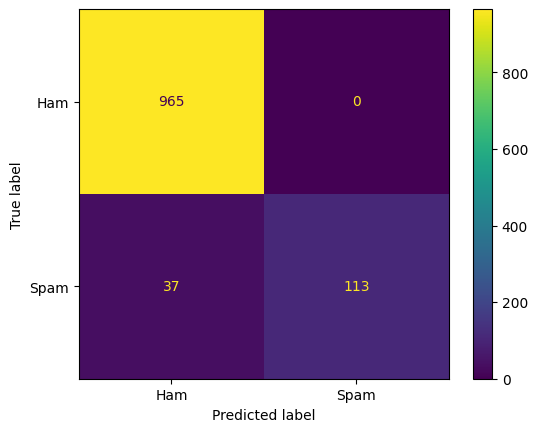

In [27]:
cm=confusion_matrix(y_test, prediction)
disp= ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot()

# Testing on Spamtest.txt

In [28]:
test= vectorizer.transform(["Spamtest.txt"])

In [29]:
prediction_test= model.predict(test)

In [30]:
pd.DataFrame(prediction_test, columns=['Predictions']).to_csv("Prediction_test.csv")